# Gantt Chart

This section showcases the gantt chart. It contains examples of how to create gantt charts using the [datachart.charts.GanttChart](../../../references/charts/#datachart.charts.GanttChart) function.

Looking for a specific customization? Jump straight to the [quick reference](#customizing-the-gantt-chart), which maps common tasks to the parameter or style attribute that does the job.

As mentioned above, the gantt charts are created using the `GanttChart` function found in the [datachart.charts](../../../references/charts/) module. Let's import it:

In [1]:
from datachart.charts import GanttChart

## Gantt Chart Input Attributes

The `GanttChart` function accepts keyword arguments for chart configuration. The main argument is `data`, a list of task records. Each record names its `task` and its `start` and `end` as temporal objects — `datetime.date`, `datetime.datetime`, `numpy.datetime64`, or pandas `Timestamp`; date strings are never parsed. A record may add its `group`, the `progress` done, the tasks it `depends_on`, and its own `emphasis`; a task whose `end` equals its `start` is a milestone. A list of such lists draws one schedule per subplot.

```python
GanttChart(
    data=[                                              # The task records (or list of lists for multiple schedules)
        {
            "task": str,                                # The task name, unique within the chart; its row label
            "start": Union[date, datetime],             # When the task starts
            "end": Union[date, datetime],               # When the task ends, never before start; equal to start for a milestone
            "group": Optional[str],                     # The task group: one color and legend entry per group
            "progress": Optional[float],                # The fraction done, in [0, 1]; drawn as an inner bar
            "depends_on": Optional[List[str]],          # The names of the tasks this task depends on
            "emphasis": Optional[EMPHASIS],             # The task's own emphasis role ("background", "highlight")
        },
    ],
    style={                                             # The style of the schedule (optional)
        "plot_bar_color":              Optional[str],   # The bar color; None takes the group or palette color
        "plot_bar_alpha":              Optional[float], # The alpha of the bars
        "plot_bar_edge_width":         Optional[float], # The width of the bar edges
        "plot_bar_edge_color":         Optional[str],   # The color of the bar edges
        "plot_gantt_bar_height":       Optional[float], # The bar height, as a fraction of its row
        "plot_gantt_progress_color":   Optional[str],   # The progress bar color; None darkens the bar color
        "plot_gantt_progress_alpha":   Optional[float], # The alpha of the progress bar
        "plot_gantt_progress_height":  Optional[float], # The progress bar height, as a fraction of the bar
        "plot_gantt_dependency_color": Optional[str],   # The color of the dependency arrows
        "plot_gantt_dependency_width": Optional[float], # The line width of the dependency arrows
        "plot_gantt_dependency_style": Optional[str],   # The arrow head, as a matplotlib arrow style
        "plot_gantt_dependency_zorder": Optional[float],# The zorder of the dependency arrows
        "plot_gantt_dependency_entry": Optional[GANTT_ARROW_ENTRY], # The side an arrow enters the task ("top", "left")
        "plot_gantt_summary_height":   Optional[float], # The height of a group's summary bar, as a fraction of its row
        "plot_gantt_summary_color":    Optional[str],   # The color of the summary bars; None takes the group color
        "plot_gantt_group_gap":        Optional[float], # The gap before each group header, in rows
        "plot_gantt_milestone_marker": Optional[LINE_MARKER], # The marker of a milestone
        "plot_gantt_milestone_size":   Optional[float], # The size of the milestone marker, in points
        "plot_gantt_today_color":      Optional[str],   # The color of the today line
        "plot_gantt_today_style":      Optional[LINE_STYLE], # The line style of the today line
        "plot_gantt_today_width":      Optional[float], # The line width of the today line
        "plot_gantt_today_alpha":      Optional[float], # The alpha of the today line
    },
    subtitle=Optional[str],                             # The subtitle of the schedule (or list for multiple schedules)
    title=Optional[str],                                # The title of the chart
    xlabel=Optional[str],                               # The label of the date axis
    ylabel=Optional[str],                               # The label of the task axis
    figsize=Optional[Tuple[float, float]],              # The figure size in inches
    max_cols=Optional[int],                             # Maximum number of schedules per row (1 by default)

    xmin=Optional[Union[date, datetime]],               # The start of the date window
    xmax=Optional[Union[date, datetime]],               # The end of the date window
    period=Optional[GANTT_DATE_PERIOD],                       # Divide the date axis into periods ("day", "week", "month", "quarter", "year")
    xticks_format=Optional[DATE_FORMAT],                # The date tick format (a DATE_FORMAT or strftime pattern)
    xtickrotate=Optional[int],                          # The rotation of the date tick labels
    ytickrotate=Optional[int],                          # The rotation of the task labels

    show_group_headers=Optional[bool],                  # Whether to give each group a header row and summary bar
    show_legend=Optional[bool],                         # Whether to list the groups (on when any task has a group, headers off)
    legend=Optional[LegendSettingAttrs],                # The legend title, location, and columns
    show_grid=Optional[SHOW_GRID],                      # Which grid lines to show ("both", "x", "y")
    show_values=Optional[GANTT_VALUE],                  # The label past each bar ("duration", "progress")
    value_format=Optional[str],                         # The format of the value labels
    show_dependencies=Optional[bool],                   # Whether to draw the dependency arrows
    show_today=Optional[bool],                          # Whether to draw the today line
    today=Optional[Union[date, datetime]],              # The date of the today line (the current date by default)
    today_label=Optional[str],                          # The label at the foot of the today line

    sort=Optional[SORT],                                # The row order (None, "ascending", "descending")
    sort_by=Optional[GANTT_SORT_KEY],                   # What the rows sort by ("start", "group")

    emphasis=Optional[EMPHASIS],                        # The emphasis role of the whole schedule
    emphasis_rule=Optional[EmphasisRuleAttrs],          # Highlight the tasks matching a rule on their duration in days

    vlines=Optional[List[VLineSettingAttrs]],           # Vertical lines at temporal positions
    vspans=Optional[List[VSpanSettingAttrs]],           # Vertical bands between temporal positions
    texts=Optional[List[TextSettingAttrs]],             # Text annotations
)
```

For more details, see the [datachart.charts.GanttChart](../../../references/charts/#datachart.charts.GanttChart) function.

## Basics

The examples in this guide share one dataset: the plan for relaunching a public library's website, a fourteen-week project run by a small team. The plan is illustrative, written out in a hidden cell with the shape such projects take: discovery first, design and content in parallel, development once the designs settle, and testing and launch at the end. `plan` holds the task records; the project stands on 3 June 2024, `TODAY`.

In [2]:
import datetime

TODAY = datetime.date(2024, 6, 3)


def week(n, day=0):
    """The Monday of project week `n` (week 0 starts 1 April 2024), plus `day` days."""
    return datetime.date(2024, 4, 1) + datetime.timedelta(weeks=n, days=day)


plan = [
    {"task": "Stakeholder interviews", "start": week(0), "end": week(2), "group": "Discovery", "progress": 1.0},
    {"task": "Usage analytics review", "start": week(0, 2), "end": week(2, 2), "group": "Discovery", "progress": 1.0},
    {"task": "Information architecture", "start": week(2), "end": week(4), "group": "Design", "progress": 1.0,
     "depends_on": ["Stakeholder interviews", "Usage analytics review"]},
    {"task": "Visual design", "start": week(4), "end": week(8), "group": "Design", "progress": 0.75,
     "depends_on": ["Information architecture"]},
    {"task": "Design sign-off", "start": week(8), "end": week(8), "group": "Design",
     "depends_on": ["Visual design"]},
    {"task": "Content migration", "start": week(3), "end": week(11), "group": "Content", "progress": 0.4,
     "depends_on": ["Information architecture"]},
    {"task": "Catalogue search", "start": week(6), "end": week(11), "group": "Development", "progress": 0.2,
     "depends_on": ["Information architecture"]},
    {"task": "Page templates", "start": week(8), "end": week(12), "group": "Development",
     "depends_on": ["Design sign-off"]},
    {"task": "Accessibility audit", "start": week(11), "end": week(13), "group": "Launch",
     "depends_on": ["Page templates", "Catalogue search"]},
    {"task": "Go live", "start": week(13), "end": week(14), "group": "Launch",
     "depends_on": ["Accessibility audit", "Content migration"]},
]

The data is a list of dictionaries, one per task. `start` and `end` are `datetime.date` objects; the other keys are optional.

In [3]:
plan[3]

{'task': 'Visual design',
 'start': datetime.date(2024, 4, 29),
 'end': datetime.date(2024, 5, 27),
 'group': 'Design',
 'progress': 0.75,
 'depends_on': ['Information architecture']}

**Basic example.** Only the `data` argument is required to draw the gantt chart. Every task is a bar from its start to its end on the date axis, one row per task in input order, the first at the top. The date ticks are concise: the month where it changes and the day between. Tasks carrying a `group` take one color per group, and the legend lists the groups; a task with a `progress` fraction fills that part of its bar with a darker inner bar; the design sign-off, which ends when it starts, is a milestone marker.

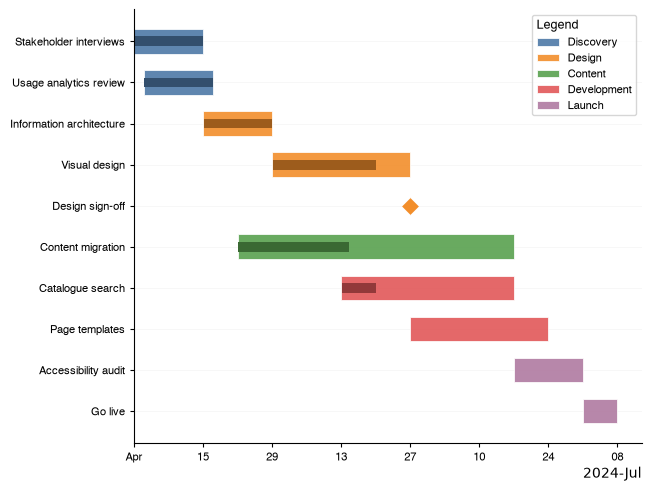

In [4]:
GanttChart(
    # add the data to the chart
    data=plan
).show()

## Customizing the Gantt Chart

Every customization is either a keyword argument of `GanttChart` or a `plot_gantt_*` (or `plot_bar_*`) attribute of its `style` dictionary. The table maps common tasks to the one you need and links to the subsection that shows it.

| I want to…                                  | Use                                                                     | See |
| :------------------------------------------ | :---------------------------------------------------------------------- | :-- |
| add a title or axis labels                  | `title`, `xlabel`, `ylabel`                                             | [Title, labels, and figure size](#title-labels-and-figure-size) |
| resize the figure                           | `figsize`                                                               | [Title, labels, and figure size](#title-labels-and-figure-size) |
| zoom to a date window                       | `xmin`, `xmax`                                                          | [Date axis](#date-axis) |
| change or rotate the date labels            | `xticks_format`, `xtickrotate`                                          | [Date axis](#date-axis) |
| divide the date axis into weeks or months   | `period`                                                                | [Periods](#periods) |
| order the rows by start or by group         | `sort`, `sort_by`                                                       | [Row order](#row-order) |
| hide or move the group legend               | `show_legend`, `legend`                                                 | [Groups and legend](#groups-and-legend) |
| give each group a header row and summary bar | `show_group_headers`                                                   | [Group headers](#group-headers) |
| mark a milestone                            | a task with `end` equal to `start`                                      | [Milestones](#milestones) |
| label each bar with its duration or progress | `show_values`, `value_format`                                          | [Value labels](#value-labels) |
| draw the dependency arrows                  | `show_dependencies`, `style={"plot_gantt_dependency_entry": ...}`     | [Dependencies](#dependencies) |
| mark today or a period                      | `show_today`, `today`, `today_label`, `vlines`, `vspans`                | [Today line and reference lines](#today-line-and-reference-lines) |
| change the bar, progress, or arrow style    | `style={"plot_gantt_bar_height": ..., "plot_gantt_progress_color": ...}` | [Gantt style](#gantt-style) |
| highlight some tasks, mute the rest         | `emphasis` record key, `emphasis_rule`, `emphasis`                      | [Emphasis](#emphasis) |
| draw several schedules                      | `data` as a list of lists, `subtitle`, `max_cols`                       | [Multiple schedules](#multiple-schedules) |
| place a schedule beside other charts        | `Grid`                                                                  | [Composing gantt charts](#composing-gantt-charts) |
| save the chart to a file                    | `save_figure`                                                           | [Saving the Chart as an Image](#saving-the-chart-as-an-image) |

The parameters that accept a constant, with the class in [datachart.constants](../../../references/constants/) that lists its values:

| Parameter | Constant |
| :-- | :-- |
| `period` | [`GANTT_DATE_PERIOD`](../../../references/constants/#datachart.constants.GANTT_DATE_PERIOD) |
| `show_values` | [`GANTT_VALUE`](../../../references/constants/#datachart.constants.GANTT_VALUE) |
| `sort_by` | [`GANTT_SORT_KEY`](../../../references/constants/#datachart.constants.GANTT_SORT_KEY) |
| `style={"plot_gantt_dependency_entry": ...}` | [`GANTT_ARROW_ENTRY`](../../../references/constants/#datachart.constants.GANTT_ARROW_ENTRY) |
| `figsize` | [`FIG_SIZE`](../../../references/constants/#datachart.constants.FIG_SIZE) |
| `legend={"location": ..., "alignment": ...}` | [`LEGEND_LOCATION`](../../../references/constants/#datachart.constants.LEGEND_LOCATION), [`LEGEND_ALIGN`](../../../references/constants/#datachart.constants.LEGEND_ALIGN) |
| `show_grid` | [`SHOW_GRID`](../../../references/constants/#datachart.constants.SHOW_GRID) |
| `value_format` | [`VALUE_FORMAT`](../../../references/constants/#datachart.constants.VALUE_FORMAT) |
| `sort` | [`SORT`](../../../references/constants/#datachart.constants.SORT) |
| `emphasis` | [`EMPHASIS`](../../../references/constants/#datachart.constants.EMPHASIS) |
| `xticks_format` | [`DATE_FORMAT`](../../../references/constants/#datachart.constants.DATE_FORMAT) |

The full list of style attributes is in the [datachart.typings.GanttStyleAttrs](../../../references/typings/#datachart.typings.GanttStyleAttrs) type; the full list of parameters is in the [datachart.charts.GanttChart](../../../references/charts/#datachart.charts.GanttChart) reference.

### Title, labels, and figure size

To add the chart title and the axis labels, add the `title`, `xlabel`, and `ylabel` attributes. The gantt chart is always horizontal, so the axis attributes are spatial: `xlabel` names the horizontal date axis and `ylabel` the vertical task axis.

To change the figure size, add the `figsize` attribute. The `figsize` attribute can be a tuple (width, height), values are in inches. The `datachart` package provides a [datachart.constants.FIG_SIZE](../../../references/constants/#datachart.constants.FIG_SIZE) constant, which contains some of the predefined figure sizes.

In [5]:
from datachart.constants import FIG_SIZE

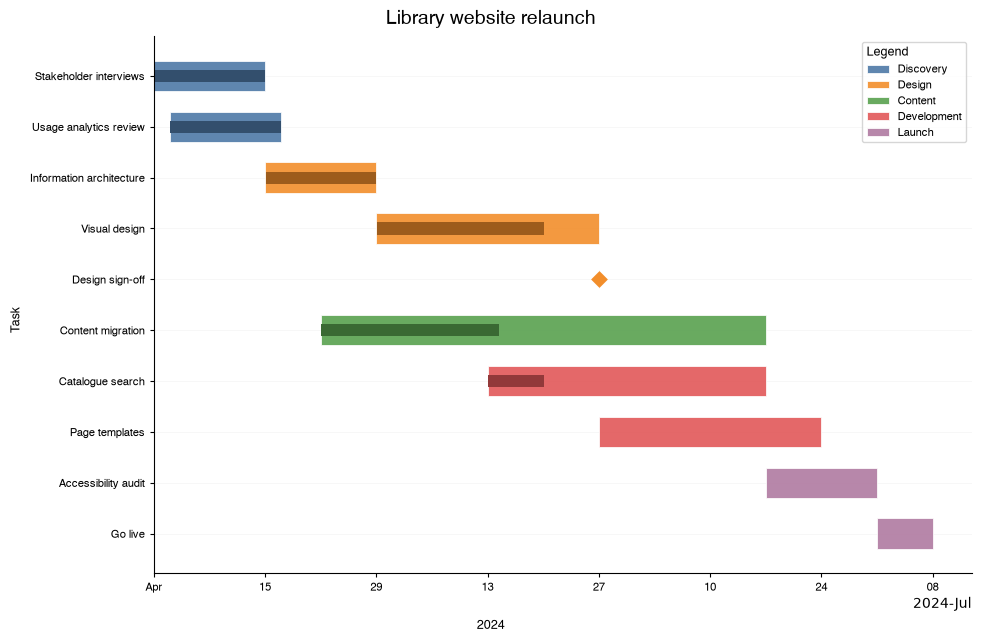

In [6]:
GanttChart(
    data=plan,
    # add the title and the axis labels
    title="Library website relaunch",
    xlabel="2024",
    ylabel="Task",
    # add to determine the figure size
    figsize=FIG_SIZE.A4_LANDSCAPE,
).show()

### Date axis

The date axis spans the tasks. To zoom to a window, add the `xmin` and `xmax` attributes as temporal objects; the bars outside the window are clipped at its edges.

The date ticks are concise by default. To print them in one format instead, add the `xticks_format` attribute with a [datachart.constants.DATE_FORMAT](../../../references/constants/#datachart.constants.DATE_FORMAT) constant or any `strftime` pattern, and `xtickrotate` to rotate the labels when they crowd.

In [7]:
from datachart.constants import DATE_FORMAT

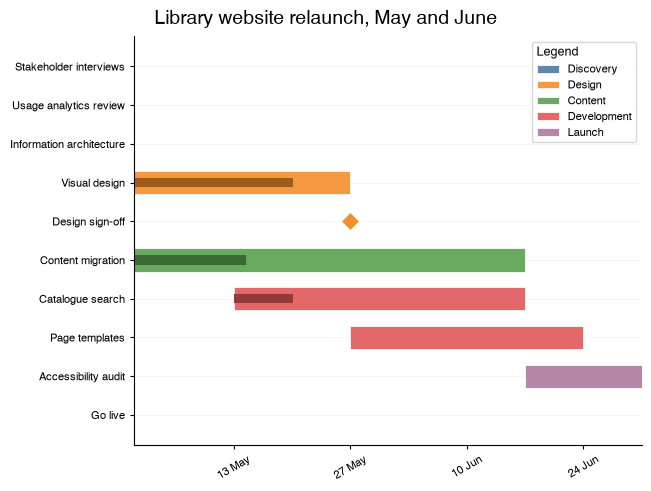

In [8]:
GanttChart(
    data=plan,
    title="Library website relaunch, May and June",
    # zoom to a date window
    xmin=datetime.date(2024, 5, 1),
    xmax=datetime.date(2024, 7, 1),
    # print every tick as day and month
    xticks_format="%d %b",
    xtickrotate=30,
).show()

### Periods

To divide the date axis into calendar periods, as project plans are printed, add the `period` attribute with a [datachart.constants.GANTT_DATE_PERIOD](../../../references/constants/#datachart.constants.GANTT_DATE_PERIOD) constant: `DAY`, `WEEK` (ISO weeks starting on Monday), `MONTH`, `QUARTER`, or `YEAR`. Lines mark the period edges, each period is labelled at its centre, and a second row names the enclosing month (for days and weeks) or year (for months and quarters). `xticks_format` sets the period labels.

In [9]:
from datachart.constants import GANTT_DATE_PERIOD

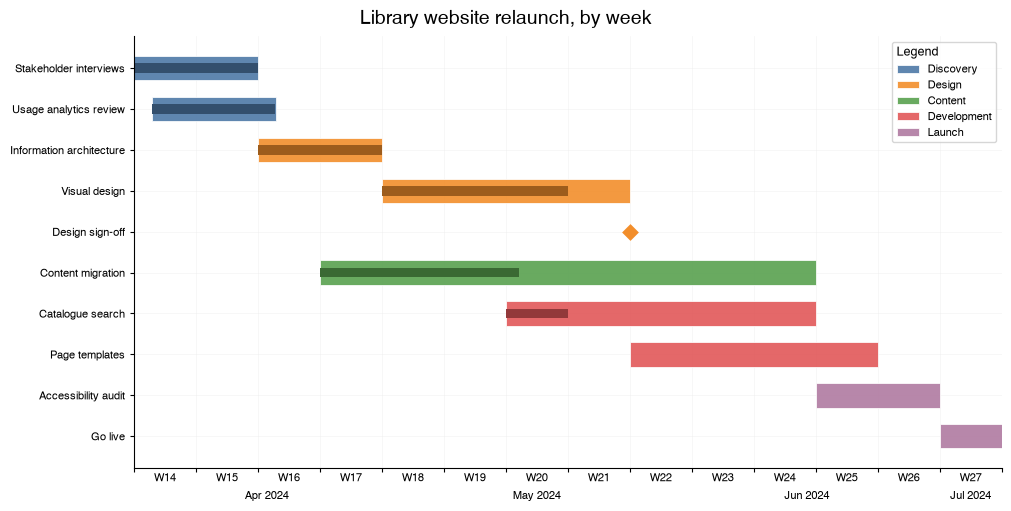

In [10]:
GanttChart(
    data=plan,
    title="Library website relaunch, by week",
    # divide the date axis into weeks, named under their months
    period=GANTT_DATE_PERIOD.WEEK,
    figsize=(10, 5),
).show()

### Row order

The rows follow the input order by default. To order them, add the `sort` attribute with a [datachart.constants.SORT](../../../references/constants/#datachart.constants.SORT) constant; the `sort_by` attribute, a [datachart.constants.GANTT_SORT_KEY](../../../references/constants/#datachart.constants.GANTT_SORT_KEY) constant, names what they sort by. By `START`, the default, every row orders by its start date. By `GROUP`, the rows cluster by group — the groups ordered by their earliest start, the tasks within a group by start — so every group reads as one block. Ties keep the input order; `sort_by` without `sort`, or `GROUP` when no task has a `group`, raises a `ValueError`.

In [11]:
from datachart.constants import SORT, GANTT_SORT_KEY

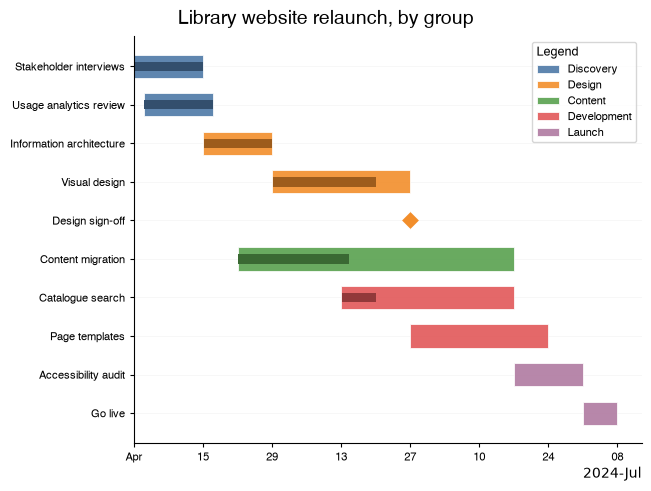

In [12]:
GanttChart(
    data=plan,
    title="Library website relaunch, by group",
    # cluster the rows by group, earliest group first
    sort=SORT.ASCENDING,
    sort_by=GANTT_SORT_KEY.GROUP,
).show()

### Groups and legend

Tasks of one `group` share a color from the theme's multiple palette, in first-seen order, and the legend lists one entry per group; it is on whenever a task carries a `group`. To hide it, set `show_legend=False`; to give it a title or move it, add the `legend` attribute, a [datachart.typings.LegendSettingAttrs](../../../references/typings/#datachart.typings.LegendSettingAttrs) dictionary. Tasks without a `group` draw in the chart's palette color and carry no legend entry.

In [13]:
from datachart.constants import LEGEND_LOCATION

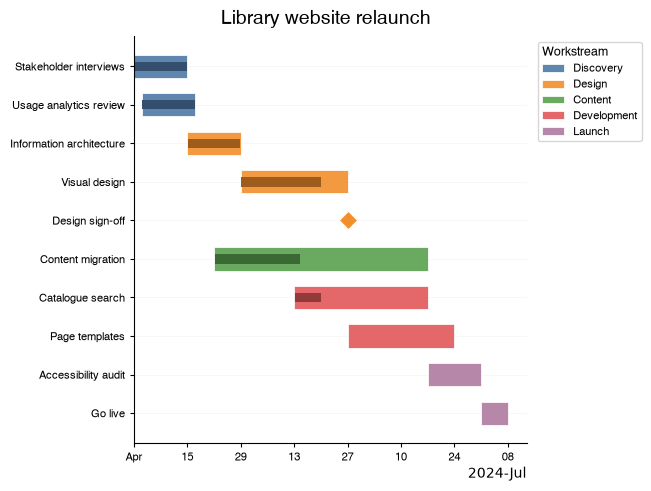

In [14]:
GanttChart(
    data=plan,
    title="Library website relaunch",
    # title the legend and place it beside the chart
    legend={"title": "Workstream", "location": LEGEND_LOCATION.OUTSIDE_RIGHT},
).show()

### Value labels

To label each bar past its end, add the `show_values` attribute with a [datachart.constants.GANTT_VALUE](../../../references/constants/#datachart.constants.GANTT_VALUE) constant: `DURATION` prints the task's duration in days, `PROGRESS` its progress as a percentage (a task without `progress` stays unlabelled). The `value_format` attribute formats the number: the days, or the progress fraction — use a [datachart.constants.VALUE_FORMAT](../../../references/constants/#datachart.constants.VALUE_FORMAT) constant or any `"{x:.1f}"` style string.

In [15]:
from datachart.constants import GANTT_VALUE

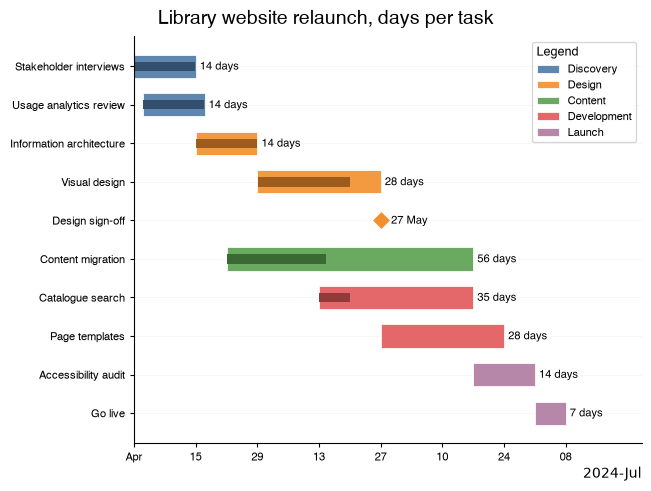

In [16]:
GanttChart(
    data=plan,
    title="Library website relaunch, days per task",
    # label each bar with its duration
    show_values=GANTT_VALUE.DURATION,
    value_format="{x:.0f} days",
).show()

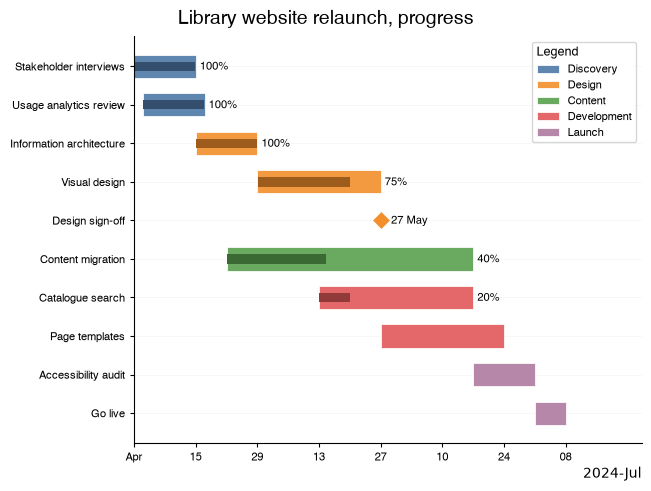

In [17]:
GanttChart(
    data=plan,
    title="Library website relaunch, progress",
    # label each bar with its progress
    show_values=GANTT_VALUE.PROGRESS,
).show()

### Group headers

To set each group apart as a block, add `show_group_headers=True`. Every group gets a header row with its name in bold and a summary bar from its first start to its last end; the group's tasks follow beneath it in their order, and a gap opens before the next header. The headers already name the groups, so the legend is off unless `show_legend` turns it on. The summary bar and the gap take the `plot_gantt_summary_height`, `plot_gantt_summary_color`, and `plot_gantt_group_gap` style attributes; without any `group`, `show_group_headers` raises a `ValueError`.

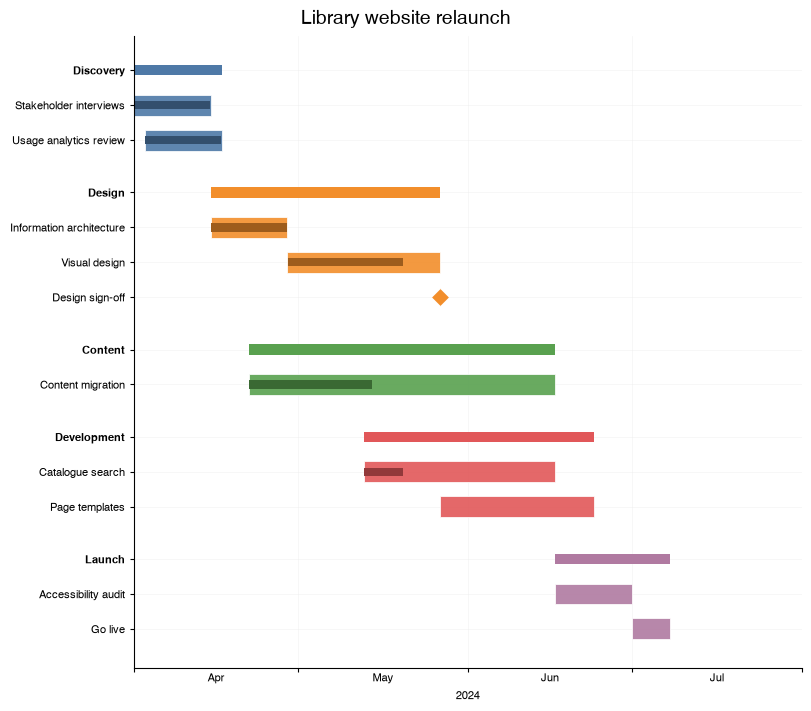

In [18]:
GanttChart(
    data=plan,
    title="Library website relaunch",
    # a header row and a summary bar for every group
    show_group_headers=True,
    period=GANTT_DATE_PERIOD.MONTH,
    figsize=(8, 7),
).show()

### Milestones

A task whose `end` equals its `start` has no duration: it is a milestone, drawn as a marker instead of a bar — the design sign-off in this plan. Under `show_values` a milestone prints its date beside the marker, in the `xticks_format` or as day and month, since there is no duration or progress to show. Dependency arrows stop at the marker's edge. The `plot_gantt_milestone_marker` and `plot_gantt_milestone_size` style attributes set its look.

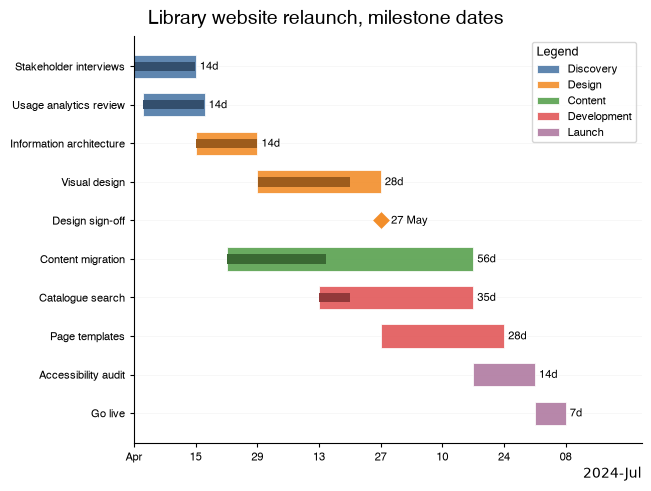

In [19]:
GanttChart(
    data=plan,
    title="Library website relaunch, milestone dates",
    # a milestone prints its date; every other task its duration
    show_values=GANTT_VALUE.DURATION,
).show()

### Dependencies

A task's `depends_on` list names the tasks that must finish before it. To draw them, add `show_dependencies=True`: an arrow leaves the end of each dependency, runs along its row, and turns down (or up) onto the start of the task depending on it. With the `plot_gantt_dependency_entry` style attribute set to `"left"`, a [datachart.constants.GANTT_ARROW_ENTRY](../../../references/constants/#datachart.constants.GANTT_ARROW_ENTRY) constant, the arrow drops from the dependency's end and enters the task's start from the left instead; a task starting before its dependency ends has no room there and is entered from the top. An unknown name in `depends_on` raises a `ValueError`, drawn or not.

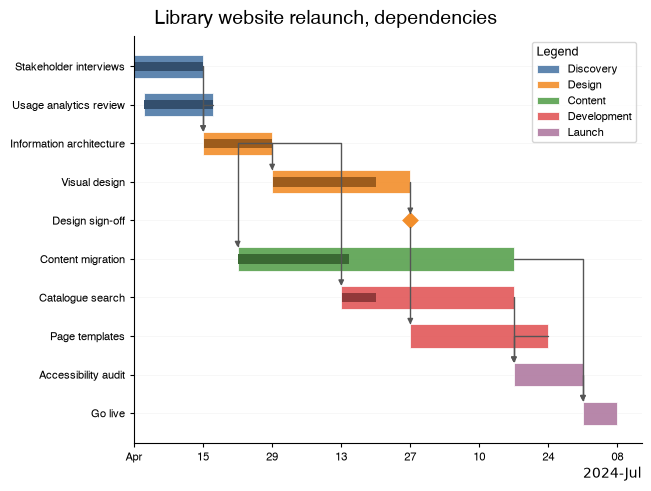

In [20]:
GanttChart(
    data=plan,
    title="Library website relaunch, dependencies",
    # draw an arrow for every dependency
    show_dependencies=True,
).show()

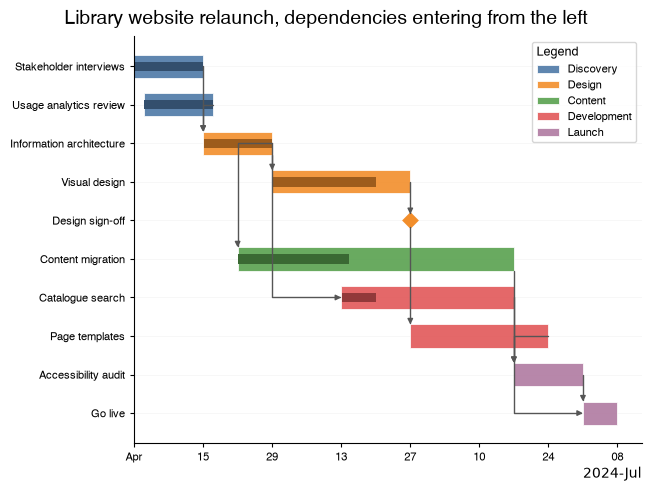

In [21]:
from datachart.constants import GANTT_ARROW_ENTRY

GanttChart(
    data=plan,
    title="Library website relaunch, dependencies entering from the left",
    show_dependencies=True,
    style={"plot_gantt_dependency_entry": GANTT_ARROW_ENTRY.LEFT},
).show()

### Today line and reference lines

To mark the present, add `show_today=True`: a dashed line crosses the chart at `today`, the current date unless the `today` attribute sets one — as here, so the guide renders the same every day. The `today_label` attribute prints a label at the foot of the line. The `vlines` and `vspans` attributes draw more lines and bands at temporal positions, such as a milestone or a holiday; see the [datachart.typings.VLineSettingAttrs](../../../references/typings/#datachart.typings.VLineSettingAttrs) and [datachart.typings.VSpanSettingAttrs](../../../references/typings/#datachart.typings.VSpanSettingAttrs) types.

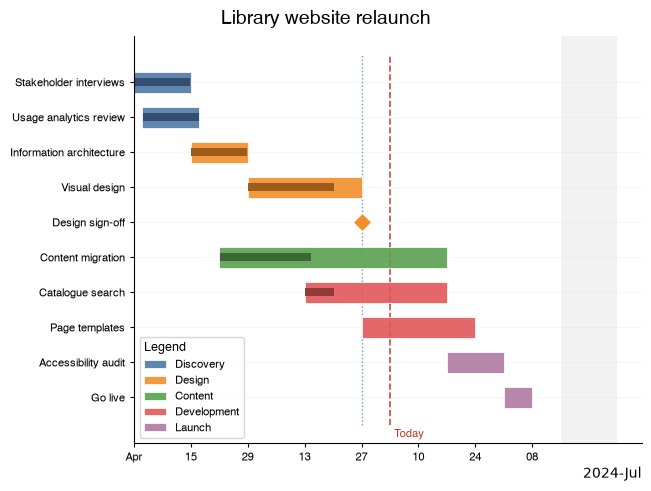

In [22]:
GanttChart(
    data=plan,
    title="Library website relaunch",
    # mark the day the project stands on
    show_today=True,
    today=TODAY,
    today_label="Today",
    # shade the summer holiday and mark the board review
    vspans={"xmin": datetime.date(2024, 7, 15), "xmax": datetime.date(2024, 7, 29), "label": "Holiday"},
    vlines={"x": datetime.date(2024, 5, 27), "style": {"plot_vline_style": ":"}},
).show()

### Gantt style

To change the style, add the `style` attribute with the corresponding attributes. The bars take the bar chart's `plot_bar_*` attributes — color, alpha, edge, hatch — and the attributes specific to a gantt chart are shown in the [datachart.typings.GanttStyleAttrs](../../../references/typings/#datachart.typings.GanttStyleAttrs) type:

| Attribute                        | Description |
| :------------------------------- | :---------- |
| `plot_gantt_bar_height`          | The height of a task bar, as a fraction of its row. |
| `plot_gantt_progress_color`      | The color of the progress bar; `None` darkens the task bar's color. |
| `plot_gantt_progress_alpha`      | The alpha (transparency) of the progress bar. |
| `plot_gantt_progress_height`     | The height of the progress bar, as a fraction of the task bar. |
| `plot_gantt_dependency_color`    | The color of the dependency arrows. |
| `plot_gantt_dependency_width`    | The line width of the dependency arrows. |
| `plot_gantt_dependency_style`    | The arrow head, as a matplotlib arrow style such as `"-|>"` or `"->"`. |
| `plot_gantt_dependency_zorder`   | The zorder of the dependency arrows. |
| `plot_gantt_dependency_entry`    | The side a dependency arrow enters its task: `"top"` or `"left"`. |
| `plot_gantt_summary_height`      | The height of a group's summary bar under `show_group_headers`, as a fraction of its row. |
| `plot_gantt_summary_color`       | The color of the summary bars; `None` takes each group's color. |
| `plot_gantt_group_gap`           | The empty space before each group header, in rows. |
| `plot_gantt_milestone_marker`    | The marker of a milestone. |
| `plot_gantt_milestone_size`      | The size of the milestone marker, in points. |
| `plot_gantt_today_color`         | The color of the today line. |
| `plot_gantt_today_style`         | The line style of the today line. |
| `plot_gantt_today_width`         | The line width of the today line. |
| `plot_gantt_today_alpha`         | The alpha (transparency) of the today line. |

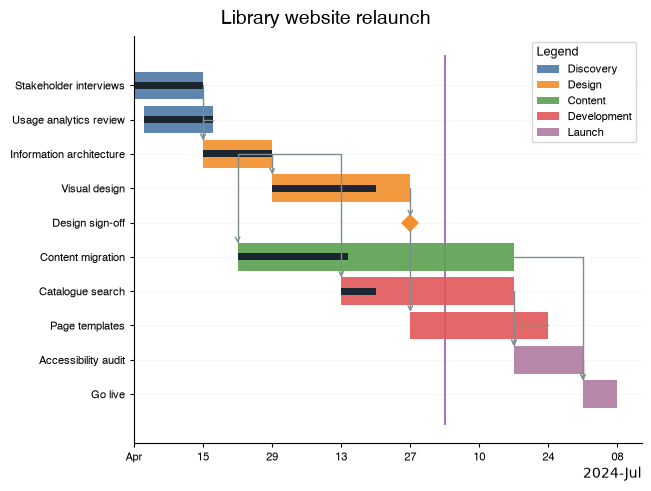

In [23]:
GanttChart(
    data=plan,
    title="Library website relaunch",
    show_dependencies=True,
    show_today=True,
    today=TODAY,
    # define the style of the schedule
    style={
        "plot_bar_edge_width": 0,
        "plot_gantt_bar_height": 0.8,
        "plot_gantt_progress_color": "#1B2631",
        "plot_gantt_progress_height": 0.25,
        "plot_gantt_dependency_color": "#7F8C8D",
        "plot_gantt_dependency_style": "->",
        "plot_gantt_today_color": "#8E44AD",
        "plot_gantt_today_style": "-",
    },
).show()

### Emphasis

A task record's own `emphasis` key takes a [datachart.constants.EMPHASIS](../../../references/constants/#datachart.constants.EMPHASIS) role: `"highlight"` strokes the bar bolder, `"background"` mutes it in the theme's muted color. The `emphasis_rule` attribute sets the roles by a rule on each task's duration in days — `{"above": v}`, `{"below": v}`, `{"between": (lo, hi)}`, `{"top": n}`, or `{"bottom": n}` — highlighting the tasks that match and muting the rest; a record's own key wins over the rule. A group whose every task is muted leaves the legend. See the [highlighting guide](../../styling/highlighting/) for emphasis across the charts.

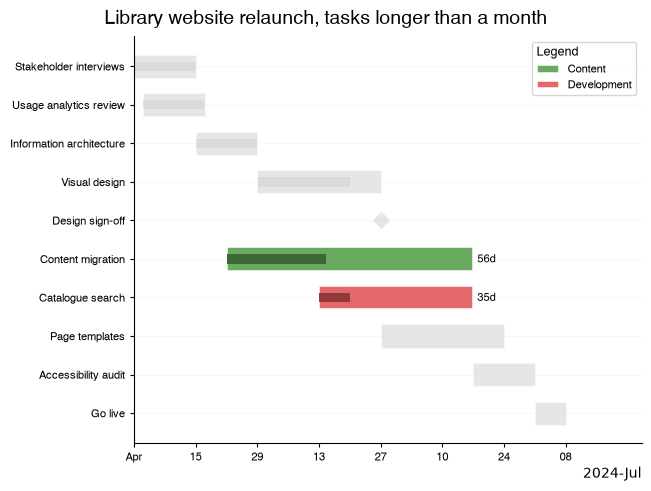

In [24]:
GanttChart(
    data=plan,
    title="Library website relaunch, tasks longer than a month",
    # highlight the tasks longer than 30 days
    emphasis_rule={"above": 30},
    show_values=GANTT_VALUE.DURATION,
).show()

## Multiple Gantt Charts

### Multiple schedules

To compare several schedules, pass a list of lists to the `data` argument. Each is drawn in its own subplot with the `subtitle` at the top, one per row unless `max_cols` sets more columns; per-schedule attributes like `style` can be lists. The example sets the plan beside what actually happened: the visual design took two weeks longer and pushed the tasks waiting on it.

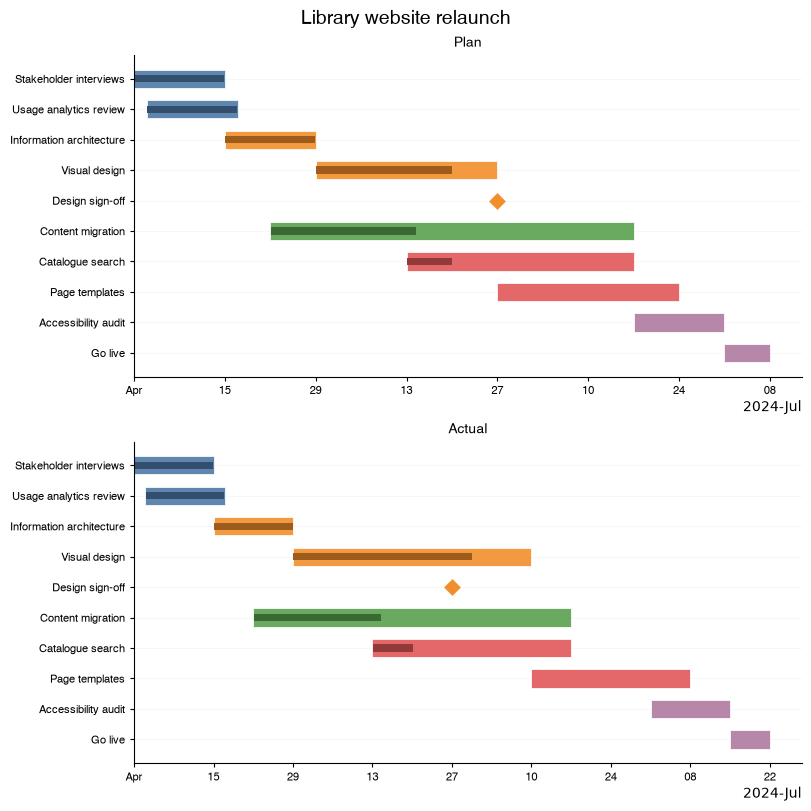

In [25]:
def delayed(record, weeks):
    shift = datetime.timedelta(weeks=weeks)
    return {**record, "start": record["start"] + shift, "end": record["end"] + shift}


# the visual design took two weeks longer; the tasks waiting on it moved with it
late = {"Page templates", "Accessibility audit", "Go live"}
actual = [
    {**r, "end": r["end"] + datetime.timedelta(weeks=2)}
    if r["task"] == "Visual design"
    else delayed(r, 2 if r["task"] in late else 0)
    for r in plan
]

GanttChart(
    # use a list of lists to define multiple schedules
    data=[plan, actual],
    subtitle=["Plan", "Actual"],
    title="Library website relaunch",
    show_legend=False,
    figsize=(8, 8),
).show()

### Composing gantt charts

A gantt chart draws time along its horizontal axis and tasks down its vertical one, so there is no shared coordinate space to overlay another chart on: [datachart.utils.Panel](../../../references/utils/#datachart.utils.Panel) rejects a gantt figure. [datachart.utils.Grid](../../../references/utils/#datachart.utils.Grid) arranges it beside other charts. The example sets the schedule over a bar chart of the days each group takes.

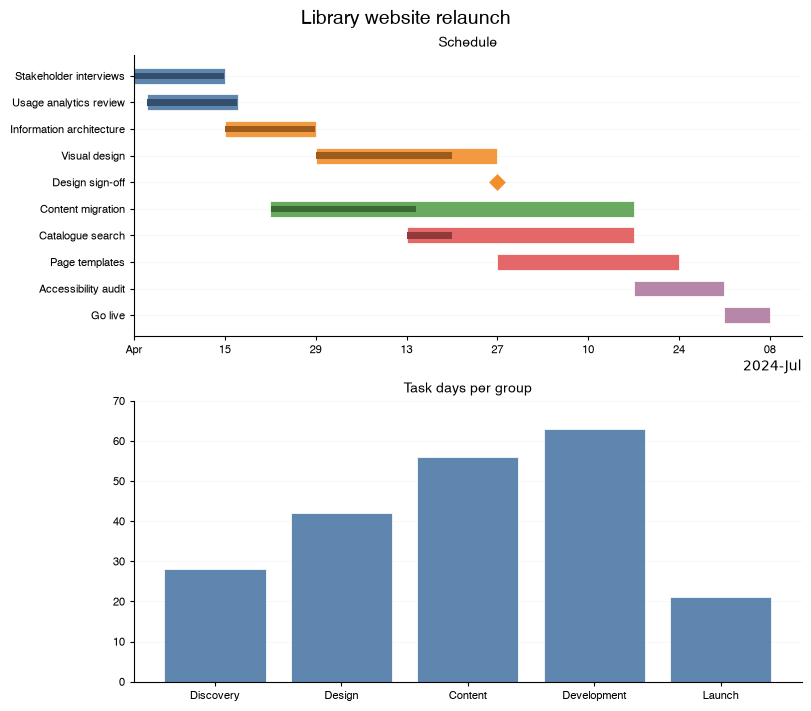

In [26]:
from datachart.charts import BarChart
from datachart.utils import Grid

groups = []
for record in plan:
    if record["group"] not in groups:
        groups.append(record["group"])
days = [
    {"label": group, "y": sum((r["end"] - r["start"]).days for r in plan if r["group"] == group)}
    for group in groups
]

schedule = GanttChart(data=plan, title="Schedule", show_legend=False)
effort = BarChart(data=days, title="Task days per group", figsize=(6.4, 2.4))

Grid([[schedule], [effort]], title="Library website relaunch", figsize=(8, 7)).show()

### Themes

A theme sets the palette, the fonts, and the bar, arrow, and today-line styles of every chart at once; themes that tell series apart by hatching give each task group its own hatch. See the [Theme Gallery](../../styling/theme-gallery/) for the whole suite under each theme. Apply one with [datachart.config.Config.set_theme](../../../references/config/#datachart.config.Config.set_theme) as the [Themes](../../styling/themes/) guide shows.

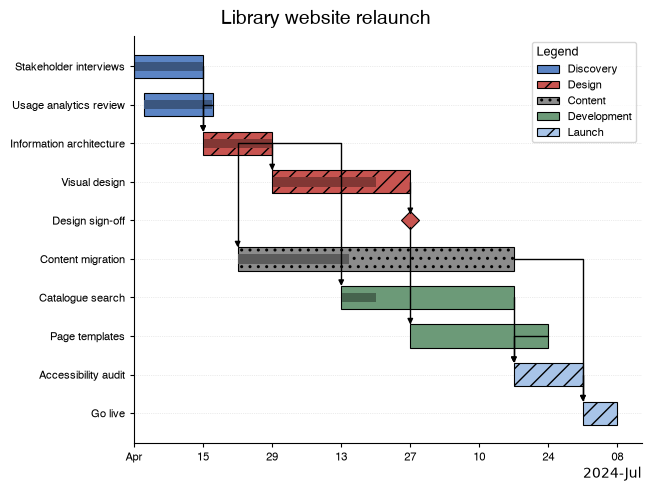

In [27]:
from datachart.config import config
from datachart.constants import THEME

config.set_theme(THEME.HATCH)
figure = GanttChart(data=plan, title="Library website relaunch", show_dependencies=True)
config.set_theme(THEME.DEFAULT)
figure.show()

## Saving the Chart as an Image

To save the chart as an image, use the [datachart.utils.save_figure](../../../references/utils#datachart.utils.save_figure) function.

In [28]:
from datachart.utils import save_figure

figure = GanttChart(data=plan, title="Library website relaunch")
save_figure(figure, "./fig_gantt_chart.png", dpi=300)

['./fig_gantt_chart.png']